In [3]:
import numpy as np
import matplotlib.pyplot as plt


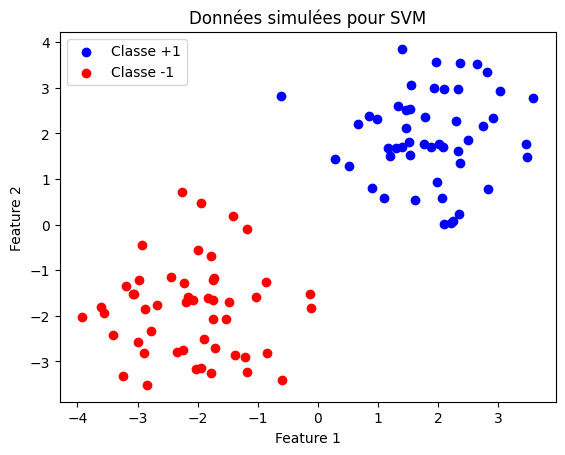

In [4]:
# Fixer la graine pour la reproductibilité
np.random.seed(42)

# Données pour deux classes
X_pos = np.random.randn(50, 2) + np.array([2, 2])
X_neg = np.random.randn(50, 2) + np.array([-2, -2])

# Fusion des données
X = np.vstack((X_pos, X_neg))

# Labels : +1 et -1 (obligatoire pour SVM)
y = np.hstack((np.ones(50), -np.ones(50)))
# Visualisation des données
plt.scatter(X_pos[:, 0], X_pos[:, 1], color='blue', label='Classe +1')
plt.scatter(X_neg[:, 0], X_neg[:, 1], color='red', label='Classe -1')
plt.title('Données simulées pour SVM')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

In [5]:
class SVC:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):
        """
        learning_rate : pas d'apprentissage
        lambda_param  : paramètre de régularisation
        n_iters       : nombre d'itérations
        """
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.w = None
        self.b = None

    def fit(self, X, y):
        """
        Entraînement du SVC avec la hinge loss
        """
        n_samples, n_features = X.shape

        # Initialisation des paramètres
        self.w = np.zeros(n_features)
        self.b = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):

                condition = y[idx] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                    # Mise à jour seulement du terme de régularisation
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Mise à jour complète (hinge loss)
                    self.w -= self.lr * (
                        2 * self.lambda_param * self.w - np.dot(x_i, y[idx])
                    )
                    self.b -= self.lr * y[idx]

    def predict(self, X):
        """
        Prédiction des classes (+1 ou -1)
        """
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)


In [6]:
svc = SVC(learning_rate=0.001, lambda_param=0.01, n_iters=1000)
svc.fit(X, y)
y_pred = svc.predict(X)


In [7]:
def plot_decision_boundary(X, y, model):
    plt.figure(figsize=(6, 6))

    # Points
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Classe +1")
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], label="Classe -1")

    # Droite de décision
    x1 = np.min(X[:, 0])
    x2 = np.max(X[:, 0])
    y1 = (model.w[0] * x1 - model.b) / (-model.w[1])
    y2 = (model.w[0] * x2 - model.b) / (-model.w[1])

    plt.plot([x1, x2], [y1, y2], 'k')

    plt.legend()
    plt.title("SVC from scratch (Linear Kernel)")
    plt.show()


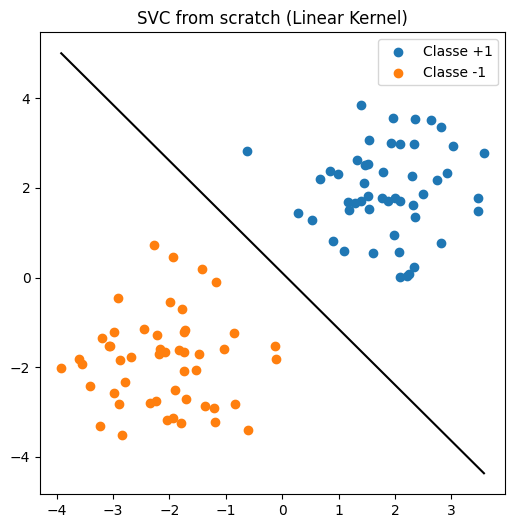

In [8]:
plot_decision_boundary(X, y, svc)
